# Splines cúbicos

In [1]:
def Spline(x: float, x0: float, pars: dict[str, float]) -> float:
    a = pars["a"]
    b = pars["b"]
    c = pars["c"]
    d = pars["d"]
    return a + b * (x - x0) + c * (x - x0) ** 2 + d * (x - x0) ** 3

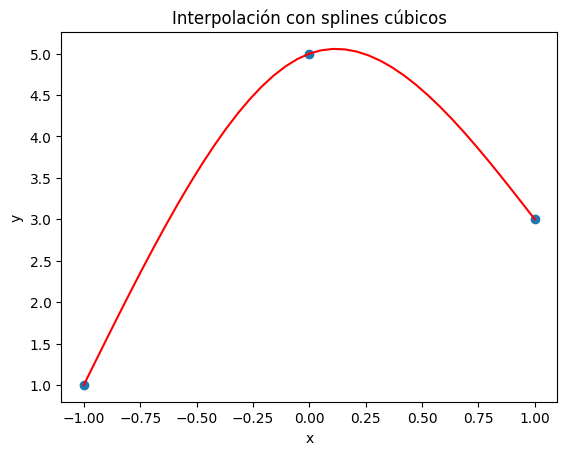

In [4]:
import matplotlib.pyplot as plt
import numpy as np

xs = [-1, 0, 1]
ys = [1, 5, 3]
s = [
    {"a": 1, "b": 5.5, "c": 0, "d": -1.5},
    {"a": 5, "b": 1, "c": -4.5, "d": 1.5},
]
for i, x_i in enumerate(xs[:-1]):
    _x = np.linspace(x_i, xs[i + 1], 20)
    _y = Spline(_x, x_i, s[i])
    plt.plot(_x, _y, color="red")

plt.scatter(xs, ys)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolación con splines cúbicos")
plt.show()

### prueba

det(A) = -7.999999999999998  -> distinto de 0, sistema resoluble para cualquier m

Coeficientes S0: {'a': np.float64(1.0), 'b': np.float64(-26.0), 'c': np.float64(54.0), 'd': np.float64(-24.0)}
Coeficientes S1: {'a': np.float64(5.0), 'b': np.float64(10.0), 'c': np.float64(-18.0), 'd': np.float64(6.0)}


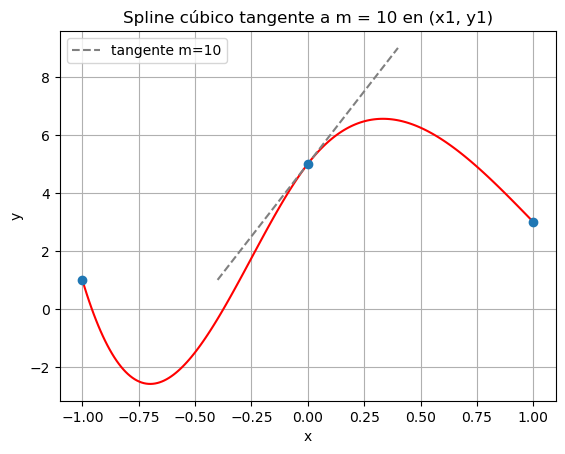

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def Spline(x, xi, coef):
    """Evalúa un tramo cúbico S(x) = a + b(x-xi) + c(x-xi)^2 + d(x-xi)^3."""
    return (
        coef["a"]
        + coef["b"] * (x - xi)
        + coef["c"] * (x - xi) ** 2
        + coef["d"] * (x - xi) ** 3
    )


def dSpline(x, xi, coef):
    """Derivada de un tramo cúbico."""
    return coef["b"] + 2 * coef["c"] * (x - xi) + 3 * coef["d"] * (x - xi) ** 2


xs = [-1, 0, 1]
ys = [1, 5, 3]
m = 10  # pendiente deseada en el punto interior (x1, y1)


A = np.array([
    # S0(x0) = y0
    [1, 0, 0, 0, 0, 0, 0, 0],
    # S0(x1) = y1
    [1, 1, 1, 1, 0, 0, 0, 0],
    # S1(x1) = y1
    [0, 0, 0, 0, 1, 0, 0, 0],
    # S1(x2) = y2
    [0, 0, 0, 0, 1, 1, 1, 1],
    # S0'(x1) = S1'(x1)   (continuidad de la 1a derivada)
    [0, 1, 2, 3, 0, -1, 0, 0],
    # S0''(x1) = S1''(x1) (continuidad de la 2a derivada)
    [0, 0, 2, 6, 0, 0, -2, 0],
    # Condición de tangencia deseada: S1'(x1) = m
    [0, 0, 0, 0, 0, 1, 0, 0],
    # Condición natural en el extremo derecho: S1''(x2) = 0
    [0, 0, 0, 0, 0, 0, 2, 6],
], dtype=float)

B = np.array([1, 5, 5, 3, 0, 0, m, 0], dtype=float)

print("det(A) =", np.linalg.det(A), " -> distinto de 0, sistema resoluble para cualquier m")

coeficientes = np.linalg.solve(A, B)
a0, b0, c0, d0, a1, b1, c1, d1 = coeficientes

print("\nCoeficientes S0:", dict(a=a0, b=b0, c=c0, d=d0))
print("Coeficientes S1:", dict(a=a1, b=b1, c=c1, d=d1))

s = [
    {"a": a0, "b": b0, "c": c0, "d": d0},
    {"a": a1, "b": b1, "c": c1, "d": d1},
]



for i, x_i in enumerate(xs[:-1]):
    _x = np.linspace(x_i, xs[i + 1], 100)
    _y = Spline(_x, x_i, s[i])
    plt.plot(_x, _y, color="red")

# Línea tangente en (x1, y1) para visualizar que el spline sí es tangente a m
x1, y1 = xs[1], ys[1]
_xt = np.linspace(x1 - 0.4, x1 + 0.4, 10)
plt.plot(_xt, y1 + m * (_xt - x1), "--", color="gray", label=f"tangente m={m}")

plt.scatter(xs, ys, zorder=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spline cúbico tangente a m = 10 en (x1, y1)")
plt.legend()
plt.grid()
plt.show()